# **MÓDULO 13**
# Projeto - Fundamentos da Descoberta de Dados

Nesse projeto trabalharemos com a base de dados de produtos de um supermercado do Chile.
A ideia é que vocês apliquem os conceitos estatísticos vistos no último módulo, mais os conceitos de visualizações de dados através de gráficos e finalizem publicando no seu github!

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

Faça a leitura dos dados do arquivo CSV:


Altere o código abaixo de acordo com seu diretório.

In [2]:
df = pd.read_csv("MODULO7_PROJETOFINAL_BASE_SUPERMERCADO-MODULO7_PROJETOFINAL_BASE_SUPERMERCADO.csv")

df.head(10)


,title,Marca,Preco_Normal,Preco_Desconto,Preco_Anterior,Desconto,Categoria
0,"Pack 12 un, Leche extra proteína 1 L",Loncoleche,19788,0,0,0,lacteos
1,"Pack 12 un, Leche chocolate receta original 1 L",Soprole,18228,0,0,0,lacteos
2,"Pack 12 un, Leche semidescremada chocolate 1 L",Soprole,18228,0,0,0,lacteos
3,"Pack 12 un, Leche semidescremada frutilla 1 L",Soprole,18228,0,0,0,lacteos
4,"Pack 12 un, Leche sin lactosa chocolate 1 L",Loncoleche,17988,0,0,0,lacteos
5,"Pack 12 un, Leche sin lactosa frutilla 1 L",Loncoleche,17988,0,0,0,lacteos
6,"Pack 12 un, Leche saborizada light chocolate 1 L",Loncoleche,17988,0,0,0,lacteos
7,"Pack 12 un, Leche saborizada frutilla 1 L",Colun,17388,0,0,0,lacteos
8,"Pack 12 un, Leche saborizada vainilla 1 L",Colun,17388,0,0,0,lacteos
9,"Pack 12 un, Leche saborizada manjar 1 L",Colun,17388,0,0,0,lacteos


Os campos do nosso dataframe são:

**Title:** Nome do produto.


**Marca:** A marca do produto.


**Preco_Normal:** O preço em que o produto costuma ser vendido quando não há desconto.


**Preco_Desconto:** O preço vendido após o desconto ser aplicado.


**Preco_Anterior:** Preço em que era comercializado o produto antes do desconto aplicado.


**Desconto:** Total de desconto aplicado.






As colunas que aparecem com valores 0 são para os produtos onde não tivemos descontos aplicados.


As categorias estão em espanhol!

# 1 - Traga a média e a mediana dos preços - coluna Preco_Normal - por categoria de produto.
# Identifique as categorias que parecem ter um valor de média abaixo ou acima da mediana.

In [3]:
df_media = df.groupby('Categoria')['Preco_Normal'].mean().reset_index().sort_values(by='Preco_Normal', ascending=False)


In [4]:
df_mediana = df.groupby('Categoria')['Preco_Normal'].median().reset_index().sort_values(by='Preco_Normal', ascending=False)


Digite aqui as categorias:

Categorias com Média ACIMA da Mediana Geral
-belleza-y-cuidado-personal
-Frutas
-verduras
-lacteos
-Congelados
-instantaneos-e-sopa

Unico que nao esta a cima da mediana é
-Comidas-preparadas


# 2 - Traga o desvio padrão por categoria de produto.
# Qual o comportamento da média e mediana nas categorias com maior desvio?

In [5]:
desvio_padrao_categoria = df.groupby('Categoria')['Preco_Normal'].std().reset_index()
desvio_padrao_categoria

,Categoria,Preco_Normal
0,belleza-y-cuidado-personal,2210.041719
1,comidas-preparadas,2019.911428
2,congelados,2111.539896
3,frutas,1639.151114
4,instantaneos-y-sopas,1170.232869
5,lacteos,3925.816164
6,verduras,1012.699625


Digite nesse campo o comportamento que você identificou.

Lacteos tem uma media de 2385 e uma media na de 989 tendo o maior desvio padrão


# 3 - Plot um boxplot da distribuição do Preco_Normal para a categoria que você identificou que tem o maior desvio padrão. Como é a distribuição desses dados segundo o boxplot? Você identifica muitos outliers?

Dica: Para trazer apenas os dados da categoria que você deseja você pode usar o df.loc[df['Categoria'] == 'CATEGORIA ESCOLHIDA'

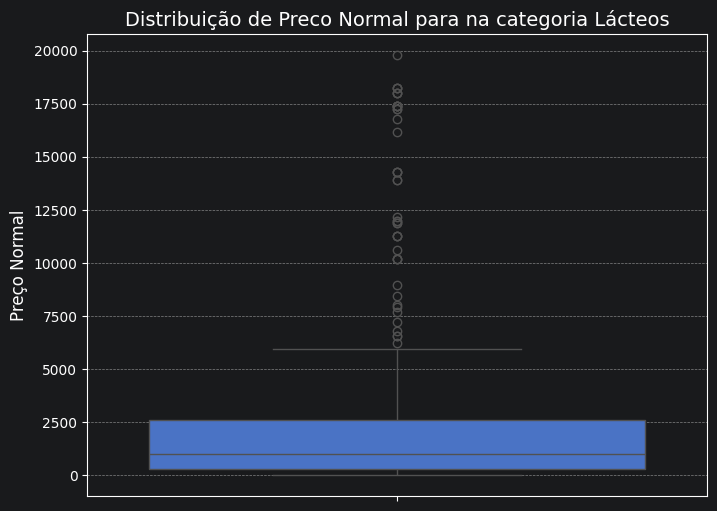

In [6]:
df_lacteos = df.loc[df['Categoria'] == 'lacteos']

plt.figure(figsize=(8, 6))
sns.boxplot(y=df_lacteos['Preco_Normal'])
plt.title('Distribuição de Preco Normal para na categoria Lácteos', fontsize=14)
plt.ylabel('Preço Normal', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


# 4 - Plote um gráfico de barras onde temos a média de descontos por categoria.

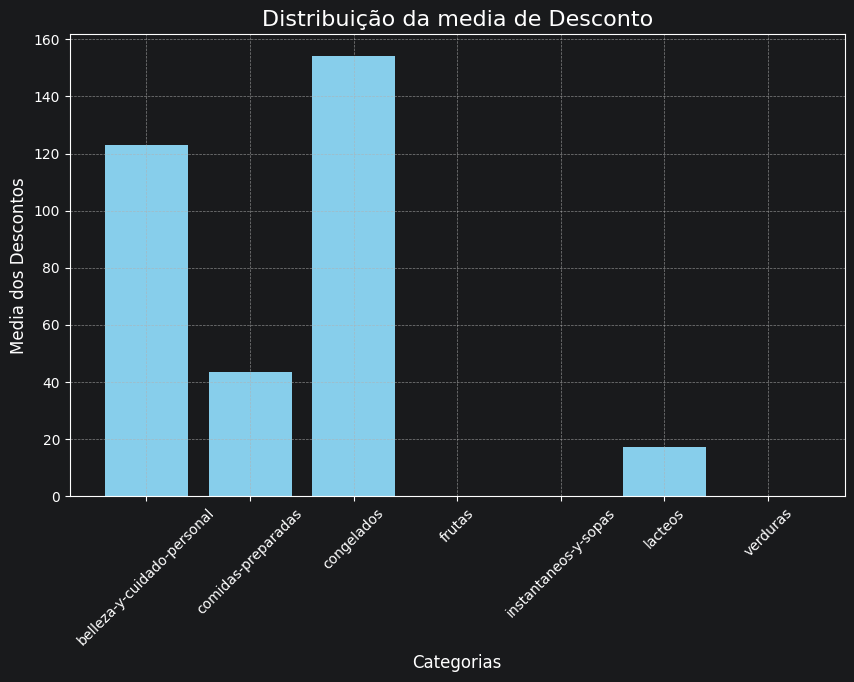

In [10]:
df_mediacs = df.groupby('Categoria')['Desconto'].mean()
plt.figure(figsize=(10, 6))
plt.bar(df_mediacs.index, df_mediacs, color='skyblue')
plt.title('Distribuição da media de Desconto', fontsize=16)
plt.xlabel('Categorias', fontsize=12)
plt.ylabel('Media dos Descontos', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()



# 5 - Plote um gráfico de mapa interativo agrupando os dados por categoria, marca e trazendo a média de desconto.

In [12]:
df_agrupadocm = df.groupby(['Categoria', 'Marca']) ['Desconto'].mean().reset_index()
fig = px.treemap(df_agrupadocm,
                 path=['Categoria', 'Marca'],
                 values='Desconto',
                 title='Descontos por Categoria e Marca',
                 color='Desconto')
fig.show()